### PCA analysis

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("../data/drug_discovery_virtual_screening_cleaned.csv")
df = df.drop(columns=["Unnamed: 0"])

features = df.drop(columns=["active"])
target = df["active"]

stnd = StandardScaler().set_output(transform='pandas')
features = stnd.fit_transform(features)

In [20]:
#First I'll run a PCA with as many components as we have features. As I observe the explained variance, I'll see which features matter
#I'll lower the number of components to see which features 
#Think I got this with 3 features
pca = PCA(n_components=13)
pca.fit(features)
index = ['PC-'+str(i+1) for i in range(13)]
PVE = pca.explained_variance_ratio_
PVE = pd.DataFrame(PVE, index=index)
PVE.head(10)

,0
PC-1,0.147350
PC-2,0.142815
PC-3,0.083791
PC-4,0.081222
PC-5,0.079249
PC-6,0.078309
PC-7,0.077503
PC-8,0.074579
PC-9,0.073761
PC-10,0.072298


In [21]:
loadings = pca.components_
loadingsDF = pd.DataFrame(loadings, index=index, columns=features.columns)
loadingsDF.round(4)

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
PC-1,0.0552,0.5862,-0.0426,-0.0027,0.0092,0.0268,0.0120,-0.2585,0.3042,-0.0240,-0.0033,0.2535,0.6530
PC-2,0.2134,-0.2212,-0.0382,0.0656,0.0115,0.0175,0.0211,-0.6142,-0.1322,-0.0265,0.0466,0.6582,-0.2607
PC-3,-0.1380,0.2124,-0.4639,0.2419,0.1033,-0.1142,0.5175,-0.0294,-0.4341,-0.0268,-0.4229,-0.0405,-0.0114
PC-4,-0.2529,0.0420,0.3736,-0.3417,0.3496,0.1761,0.3326,-0.1180,-0.0897,0.6256,0.0013,0.0259,-0.0036
PC-5,0.5862,-0.0332,-0.1595,0.0136,0.4709,0.5854,0.0633,0.2287,0.0423,-0.0699,-0.0449,-0.0112,0.0104
PC-6,0.5268,-0.0092,-0.1812,-0.4553,-0.3806,-0.3319,0.3653,0.1623,0.0611,0.2230,0.1147,0.0278,-0.0039
PC-7,-0.0498,0.2025,-0.0969,0.2428,-0.3588,0.3954,0.0754,0.0240,-0.3863,0.1553,0.6492,-0.0399,0.0185
PC-8,0.1150,-0.1713,0.0332,0.5781,-0.3079,0.1137,0.0412,0.0355,0.3702,0.5324,-0.3015,0.0032,0.0059
PC-9,0.2654,0.0601,0.4945,0.4559,0.2880,-0.4305,0.3050,0.0932,-0.0570,-0.1351,0.2835,-0.0223,0.0344
PC-10,0.0194,0.0209,0.5135,-0.1071,-0.4325,0.3696,0.3481,-0.0145,-0.0499,-0.4157,-0.3219,0.0081,-0.0054


0    0.981406
dtype: float64


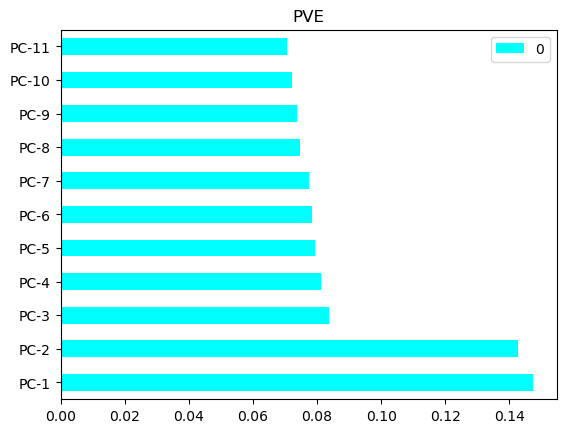

In [22]:
import matplotlib.pyplot as plt
pca = PCA(n_components=11)
pca.fit(features)
index = ['PC-'+str(i+1) for i in range(11)]
PVE = pca.explained_variance_ratio_
PVE = pd.DataFrame(PVE, index=index)
PVE.plot.barh(color='cyan',title='PVE')
print(PVE.sum())

In [23]:
loadings = pca.components_
loadingsDF = pd.DataFrame(loadings, index=index, columns=features.columns)
loadingsDF.round(4)

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction
PC-1,0.0552,0.5862,-0.0426,-0.0027,0.0092,0.0268,0.0120,-0.2585,0.3042,-0.0240,-0.0033,0.2535,0.6530
PC-2,0.2134,-0.2212,-0.0382,0.0656,0.0115,0.0175,0.0211,-0.6142,-0.1322,-0.0265,0.0466,0.6582,-0.2607
PC-3,-0.1380,0.2124,-0.4639,0.2419,0.1033,-0.1142,0.5175,-0.0294,-0.4341,-0.0268,-0.4229,-0.0405,-0.0114
PC-4,-0.2529,0.0420,0.3736,-0.3417,0.3496,0.1761,0.3326,-0.1180,-0.0897,0.6256,0.0013,0.0259,-0.0036
PC-5,0.5862,-0.0332,-0.1595,0.0136,0.4709,0.5854,0.0633,0.2287,0.0423,-0.0699,-0.0449,-0.0112,0.0104
PC-6,0.5268,-0.0092,-0.1812,-0.4553,-0.3806,-0.3319,0.3653,0.1623,0.0611,0.2230,0.1147,0.0278,-0.0039
PC-7,-0.0498,0.2025,-0.0969,0.2428,-0.3588,0.3954,0.0754,0.0240,-0.3863,0.1553,0.6492,-0.0399,0.0185
PC-8,0.1150,-0.1713,0.0332,0.5781,-0.3079,0.1137,0.0412,0.0355,0.3702,0.5324,-0.3015,0.0032,0.0059
PC-9,0.2654,0.0601,0.4945,0.4559,0.2880,-0.4305,0.3050,0.0932,-0.0570,-0.1351,0.2835,-0.0223,0.0344
PC-10,0.0194,0.0209,0.5135,-0.1071,-0.4325,0.3696,0.3481,-0.0145,-0.0499,-0.4157,-0.3219,0.0081,-0.0054


### SVM

In [27]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

features_train, features_test, target_train, target_test = train_test_split(
  features, target, test_size=0.2, stratify=target, random_state=42
)

svm = svm.SVC()
grid = {"kernel": ['linear', 'rbf'], "gamma": np.logspace(2, 100, 10), "C": [0.01, 1, 100, 1000]}
gridSVM = GridSearchCV(
    svm,
    param_grid=grid,
    n_jobs=-1,
    scoring="roc_auc",
    cv=5,
    error_score='raise'
)

gridSVM.fit(features_train, target_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 1, ...], 'gamma': array([1.0000...0000000e+100]), 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also dis

In [33]:
svm_best = gridSVM.best_estimator_
target_test_predict = svm_best.predict(features_test)
#test_prob = svm_best.predict_proba(features_test)[:, 1]

accuracy = accuracy_score(target_test, target_test_predict)
#roc_auc = roc_auc_score(target_test, test_prob)

print("=== SVM ===")
print("Best Params:", gridSVM.best_params_)
print(classification_report(target_test, target_test_predict))
#print("ROC-AUC:", roc_auc_score(target_test, test_prob))

=== SVM ===
Best Params: {'C': 100, 'gamma': np.float64(100.0), 'kernel': 'linear'}
              precision    recall  f1-score   support

         0.0       0.90      0.94      0.92       278
         1.0       0.85      0.77      0.81       122

    accuracy                           0.89       400
   macro avg       0.88      0.86      0.87       400
weighted avg       0.89      0.89      0.89       400

